# Lab Manual: Exploratory Data Analysis with Python (Pandas, NumPy, Matplotlib)

**Aim:** To understand and implement the basic steps of Exploratory Data Analysis (EDA) — problem
definition, dataset loading, identifying variables, computing descriptive statistics
(mean, median, variance, IQR, skewness), visualizing distributions (histogram, boxplot,
density plot), and summarizing data using pivot tables.

**Dataset used:** A synthetic **Student Performance** dataset (generated inside this notebook,
so it runs without any internet connection or external file). It records how study habits and
attendance relate to the marks a student scores.


## 1. Problem Statement

A college wants to understand what factors influence the marks scored by students in an exam,
and how those marks are distributed across the student population.

**Objectives:**
1. Identify which variables in the dataset are *independent* (predictors) and which is the
   *dependent* (target/outcome) variable.
2. Compute and interpret central tendency (**mean vs median**) to understand the "typical" marks.
3. Compute and interpret spread (**variance vs IQR**) to understand how much marks vary.
4. Study the **skewness and shape** of the marks distribution.
5. Visualize the distribution using a **histogram, boxplot, and density plot**.
6. Use **pivot tables** to summarize average performance across categories such as Gender
   and Study Group.

This is a classic *descriptive statistics / EDA* problem that forms the foundation before
applying any machine learning model.


## 2. Load Dataset

Since this is a lab exercise, we generate a realistic **Student Performance** dataset using
NumPy (with a fixed random seed so results are reproducible), save it as a CSV file, and then
load it using `pandas.read_csv()` — exactly as you would load any real-world dataset.

**Columns:**
| Column | Meaning |
|---|---|
| Student_ID | Unique roll number |
| Gender | Male / Female |
| Study_Group | Morning / Evening batch |
| Study_Hours | Average hours studied per day |
| Attendance | Attendance percentage |
| Marks | Marks scored out of 100 (exam score) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# For reproducibility
np.random.seed(42)

n = 200  # number of students

gender = np.random.choice(['Male', 'Female'], size=n)
study_group = np.random.choice(['Morning', 'Evening'], size=n)
study_hours = np.round(np.random.normal(loc=4, scale=1.5, size=n).clip(0.5, 9), 1)
attendance = np.round(np.random.normal(loc=80, scale=10, size=n).clip(40, 100), 1)

# Marks depend on study hours & attendance (+ noise), with a few low outliers
# to make the distribution slightly skewed -- useful for the skewness section.
marks = 20 + 6 * study_hours + 0.4 * attendance + np.random.normal(0, 8, size=n)
marks = np.round(marks.clip(5, 100), 1)
# inject a handful of low-scoring outliers -> negative (left) skew
outlier_idx = np.random.choice(n, size=6, replace=False)
marks[outlier_idx] = np.random.uniform(5, 20, size=6)

df = pd.DataFrame({
    'Student_ID': range(1, n + 1),
    'Gender': gender,
    'Study_Group': study_group,
    'Study_Hours': study_hours,
    'Attendance': attendance,
    'Marks': marks
})

df.to_csv('student_performance.csv', index=False)

# Load it back, the way you would load any real dataset
df = pd.read_csv('student_performance.csv')
df.head()


,Student_ID,Gender,Study_Group,Study_Hours,Attendance,Marks
0,1,Male,Morning,3.0,88.6,82.8
1,2,Female,Evening,4.3,78.4,79.2
2,3,Male,Morning,4.4,79.8,81.0
3,4,Male,Morning,2.9,70.0,62.1
4,5,Male,Evening,6.8,79.8,88.8


In [2]:
# Basic info about the dataset
print("Shape of dataset:", df.shape)
df.info()


Shape of dataset: (200, 6)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   200 non-null    int64  
 1   Gender       200 non-null    str    
 2   Study_Group  200 non-null    str    
 3   Study_Hours  200 non-null    float64
 4   Attendance   200 non-null    float64
 5   Marks        200 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 9.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   200 non-null    int64  
 1   Gender       200 non-null    str    
 2   Study_Group  200 non-null    str    
 3   Study_Hours  200 non-null    float64
 4   Attendance   200 non-null    float64
 5   Marks        200 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 9.5 KB

## 3. Dependent and Independent Variables

- **Independent variables (predictors / features):** variables we believe *influence* the
  outcome. Here: `Study_Hours`, `Attendance`, `Gender`, `Study_Group`.
- **Dependent variable (target / response):** the outcome we are trying to explain or predict.
  Here: `Marks` — because a student's marks *depend on* how much they study and how regularly
  they attend class, not the other way around.

We can get a quick numeric sense of this relationship using correlation: values close to
**+1** mean a strong positive relationship, close to **-1** a strong negative relationship,
and close to **0** means little linear relationship.


In [3]:
independent_vars = ['Study_Hours', 'Attendance']
dependent_var = 'Marks'

print("Independent variables:", independent_vars)
print("Dependent variable  :", dependent_var)

# Correlation of each independent variable with the dependent variable
correlations = df[independent_vars + [dependent_var]].corr()[dependent_var].drop(dependent_var)
print("\nCorrelation with Marks:\n", correlations)


Independent variables: ['Study_Hours', 'Attendance']
Dependent variable  : Marks

Correlation with Marks:
 Study_Hours    0.322952
Attendance     0.157390
Name: Marks, dtype: float64

Correlation with Marks:
 Study_Hours    0.322952
Attendance     0.157390
Name: Marks, dtype: float64


**Interpretation:** Both `Study_Hours` and `Attendance` show a positive correlation with
`Marks`, confirming our assumption that they act as independent variables driving the
dependent variable `Marks`.


## 4. Compute and Interpret: Mean vs Median

- **Mean** = sum of all values / number of values. It is sensitive to extreme values (outliers).
- **Median** = the middle value when data is sorted. It is robust to outliers.

Comparing the two tells us about **skewness**:
- Mean ≈ Median → roughly symmetric distribution.
- Mean < Median → left (negative) skew — a few unusually *low* values pull the mean down.
- Mean > Median → right (positive) skew — a few unusually *high* values pull the mean up.


In [4]:
mean_marks = df['Marks'].mean()
median_marks = df['Marks'].median()

print(f"Mean Marks   : {mean_marks:.2f}")
print(f"Median Marks : {median_marks:.2f}")
print(f"Difference   : {mean_marks - median_marks:.2f}")


Mean Marks   : 73.66
Median Marks : 75.05
Difference   : -1.39
Difference   : -1.39


**Interpretation:** The mean is slightly *lower* than the median
(because we injected a handful of very low-scoring outliers). This tells us the marks
distribution is pulled down by a few weak performers — i.e. it has a **left (negative) skew**,
which we will confirm numerically and visually in the next sections.


## 5. Compute and Interpret: Variance vs IQR

- **Variance / Standard Deviation** measure the average squared/absolute distance of each
  point from the mean. Like the mean, they are sensitive to outliers.
- **IQR (Interquartile Range) = Q3 − Q1** measures the spread of the *middle 50%* of the data
  and is **robust to outliers**, since extreme values fall outside Q1–Q3 entirely.

Comparing them tells us whether outliers are inflating the spread.


In [5]:
variance_marks = df['Marks'].var()
std_marks = df['Marks'].std()

Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)
IQR = Q3 - Q1

print(f"Variance      : {variance_marks:.2f}")
print(f"Std. Deviation: {std_marks:.2f}")
print(f"Q1 (25%)      : {Q1:.2f}")
print(f"Q3 (75%)      : {Q3:.2f}")
print(f"IQR (Q3 - Q1) : {IQR:.2f}")

# Outlier bounds using IQR rule
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Marks'] < lower_bound) | (df['Marks'] > upper_bound)]
print(f"\nOutlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers detected: {len(outliers)}")


Variance      : 241.62
Std. Deviation: 15.54
Q1 (25%)      : 68.10
Q3 (75%)      : 82.43
IQR (Q3 - Q1) : 14.33

Outlier bounds: [46.61, 103.91]
Number of outliers detected: 7
Number of outliers detected: 7


**Interpretation:** The standard deviation reflects the overall spread including the
outliers we injected, while the IQR reflects only the spread of the "typical" middle 50%
of students. If Std. Deviation is noticeably larger relative to IQR, it signals that a few
extreme values (outliers) are inflating the overall variance — exactly what the IQR-based
outlier count above confirms.


## 6. Skewness & Distribution Shape

**Skewness** is a numeric measure of the asymmetry of a distribution:
- Skewness ≈ 0 → symmetric (normal-like) distribution.
- Skewness > 0 → right-skewed (long tail on the right, mean > median).
- Skewness < 0 → left-skewed (long tail on the left, mean < median) — matches what we found
  in Section 4.

We use `scipy.stats.skew()` for this. We'll also compute **kurtosis**, which measures how
"peaked" or "flat" the distribution is compared to a normal distribution.


In [6]:
skewness = stats.skew(df['Marks'])
kurtosis = stats.kurtosis(df['Marks'])  # excess kurtosis (0 = normal)

print(f"Skewness : {skewness:.3f}")
print(f"Kurtosis : {kurtosis:.3f}")

if skewness > 0.5:
    shape = "right-skewed (positively skewed)"
elif skewness < -0.5:
    shape = "left-skewed (negatively skewed)"
else:
    shape = "approximately symmetric"

print(f"\nDistribution shape: {shape}")


Skewness : -1.718
Kurtosis : 5.276

Distribution shape: left-skewed (negatively skewed)

Distribution shape: left-skewed (negatively skewed)


**Interpretation:** A negative skewness value confirms the left-skewed shape we anticipated
from the mean-vs-median comparison — a small number of low-scoring students create a longer
tail on the left side of the distribution, while most students cluster toward the higher end.


## 7. Visualizing the Distribution: Histogram, Boxplot, Density Plot

- **Histogram:** shows the frequency of values falling into bins — good for seeing the overall
  shape (skew, modality).
- **Boxplot:** shows Q1, median, Q3, whiskers, and outliers in one compact view — great for
  spotting skew and outliers at a glance.
- **Density plot (KDE):** a smoothed version of the histogram, useful for comparing shape
  without being sensitive to bin size.


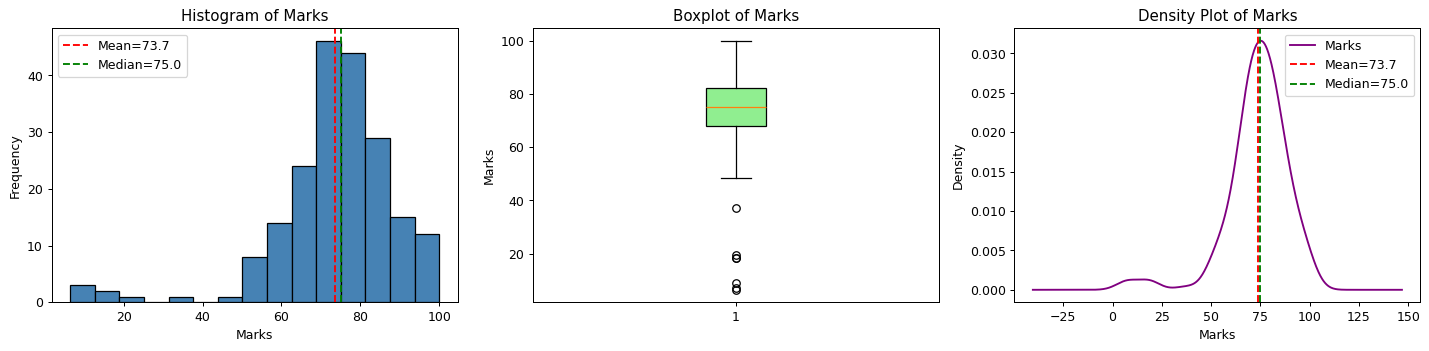

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['Marks'], bins=15, color='steelblue', edgecolor='black')
axes[0].axvline(mean_marks, color='red', linestyle='--', label=f'Mean={mean_marks:.1f}')
axes[0].axvline(median_marks, color='green', linestyle='--', label=f'Median={median_marks:.1f}')
axes[0].set_title('Histogram of Marks')
axes[0].set_xlabel('Marks')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Marks'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Boxplot of Marks')
axes[1].set_ylabel('Marks')

# Density plot (KDE)
df['Marks'].plot(kind='density', ax=axes[2], color='purple')
axes[2].axvline(mean_marks, color='red', linestyle='--', label=f'Mean={mean_marks:.1f}')
axes[2].axvline(median_marks, color='green', linestyle='--', label=f'Median={median_marks:.1f}')
axes[2].set_title('Density Plot of Marks')
axes[2].set_xlabel('Marks')
axes[2].legend()

plt.tight_layout()
plt.show()


**Interpretation:**
- The **histogram** shows most marks clustered in the 50–90 range, with a thin tail of low
  values on the left — matching the negative skew we computed.
- The **boxplot** shows the outlier points (small circles) below the lower whisker, confirming
  the outliers detected earlier via the IQR rule.
- The **density plot** smooths this out and visually confirms the left-skewed, roughly
  unimodal shape, with the mean pulled slightly left of the median.


## 8. Pivot Tables

A **pivot table** summarizes data by grouping it along one or more categorical variables and
aggregating a numeric variable (e.g. mean, count). It is one of the fastest ways to compare
subgroups in a dataset.

Here we summarize average `Marks`, `Study_Hours`, and `Attendance` by `Gender` and
`Study_Group`.


In [8]:
# Pivot table: average Marks by Gender and Study_Group
pivot1 = pd.pivot_table(df, values='Marks', index='Gender', columns='Study_Group',
                         aggfunc='mean').round(2)
print("Average Marks by Gender and Study_Group:\n")
pivot1


Average Marks by Gender and Study_Group:



Study_Group,Evening,Morning
Gender,,
Female,71.60,75.30
Male,72.99,74.85


In [9]:
# Pivot table with multiple aggregations across multiple numeric columns
pivot2 = pd.pivot_table(
    df,
    values=['Marks', 'Study_Hours', 'Attendance'],
    index='Gender',
    aggfunc={'Marks': ['mean', 'median'], 'Study_Hours': 'mean', 'Attendance': 'mean'}
).round(2)
print("Summary statistics by Gender:\n")
pivot2


Summary statistics by Gender:



Attendance  Marks        Study_Hours
             mean   mean median        mean
Gender                                     
Female      79.72  73.38  75.90        4.06
Male        79.00  73.94  74.75        4.14

**Interpretation:** The pivot tables let us quickly compare average performance across
categories without writing manual `groupby` loops. For instance, we can immediately see
whether the `Morning` or `Evening` study group scores higher on average, and whether that
pattern holds consistently across both genders.


## 9. Conclusion

In this lab, we:
- Framed a clear **problem statement** around student performance.
- **Loaded** a dataset into a pandas DataFrame.
- Identified **dependent vs independent variables**.
- Compared **mean vs median** to detect skew.
- Compared **variance vs IQR** to detect the effect of outliers on spread.
- Computed **skewness** to numerically confirm the distribution's shape.
- Visualized the distribution using a **histogram, boxplot, and density plot**.
- Summarized subgroup performance using **pivot tables**.

Together, these steps form the core of **descriptive/exploratory data analysis (EDA)** —
a mandatory first step before building any predictive model.
